In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
train_sample_path = "../train_sample.csv"
test_sample_path = "../test_sample.csv"

In [7]:
train_sample = pd.read_csv(train_sample_path)
train_sample.head()

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978
3,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Friday,10.0,9,0,medium,high,fog,1,0.833348,33.943970
4,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),day,Tuesday,NaN,7,0,medium,high,rain,2,0.966819,20.603115


In [9]:
test_sample = pd.read_csv(test_sample_path)
X_test = test_sample
X_test.head(3)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor
0,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),morning,Saturday,5.0,8,1,medium,NaN,NaN,2,1.126429
1,South Jakarta (Jakarta Selatan),East Jakarta (Jakarta Timur),evening,Saturday,NaN,9,1,low,medium,fog,2,1.121015
2,Central Jakarta (Jakarta Pusat),South Jakarta (Jakarta Selatan),morning,Friday,9.0,8,0,high,NaN,rain,1,1.109638


In [10]:
train_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   start_point                    40000 non-null  str    
 1   end_point                      40000 non-null  str    
 2   time_of_day                    40000 non-null  str    
 3   day_of_week                    40000 non-null  str    
 4   traffic_condition              25599 non-null  float64
 5   event_count                    40000 non-null  int64  
 6   is_holiday                     40000 non-null  int64  
 7   vehicle_density                25622 non-null  str    
 8   population_density             25552 non-null  str    
 9   weather                        25571 non-null  str    
 10  public_transport_availability  40000 non-null  int64  
 11  historical_delay_factor        40000 non-null  float64
 12  travel_time                    40000 non-null  float64
dt

In [11]:
train_sample.describe()

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
count,25599.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,8.455877,8.704900,0.500975,1.499525,1.009510,30.405411
std,1.829816,5.374108,0.500005,0.671201,0.162034,15.074854
min,3.000000,7.000000,0.000000,0.000000,0.750009,2.490207
25%,9.000000,7.000000,0.000000,1.000000,0.878415,18.685606
50%,9.000000,8.000000,1.000000,2.000000,1.003418,26.604213
75%,10.000000,9.000000,1.000000,2.000000,1.132044,39.771383
max,10.000000,88.000000,1.000000,2.000000,2.701010,218.832465


In [12]:
target_column = "travel_time"

numerical_columns = (
    train_sample.select_dtypes(include=["number"])
      .columns
      .drop(target_column)
)

print(numerical_columns)

Index(['traffic_condition', 'event_count', 'is_holiday',
       'public_transport_availability', 'historical_delay_factor'],
      dtype='str')


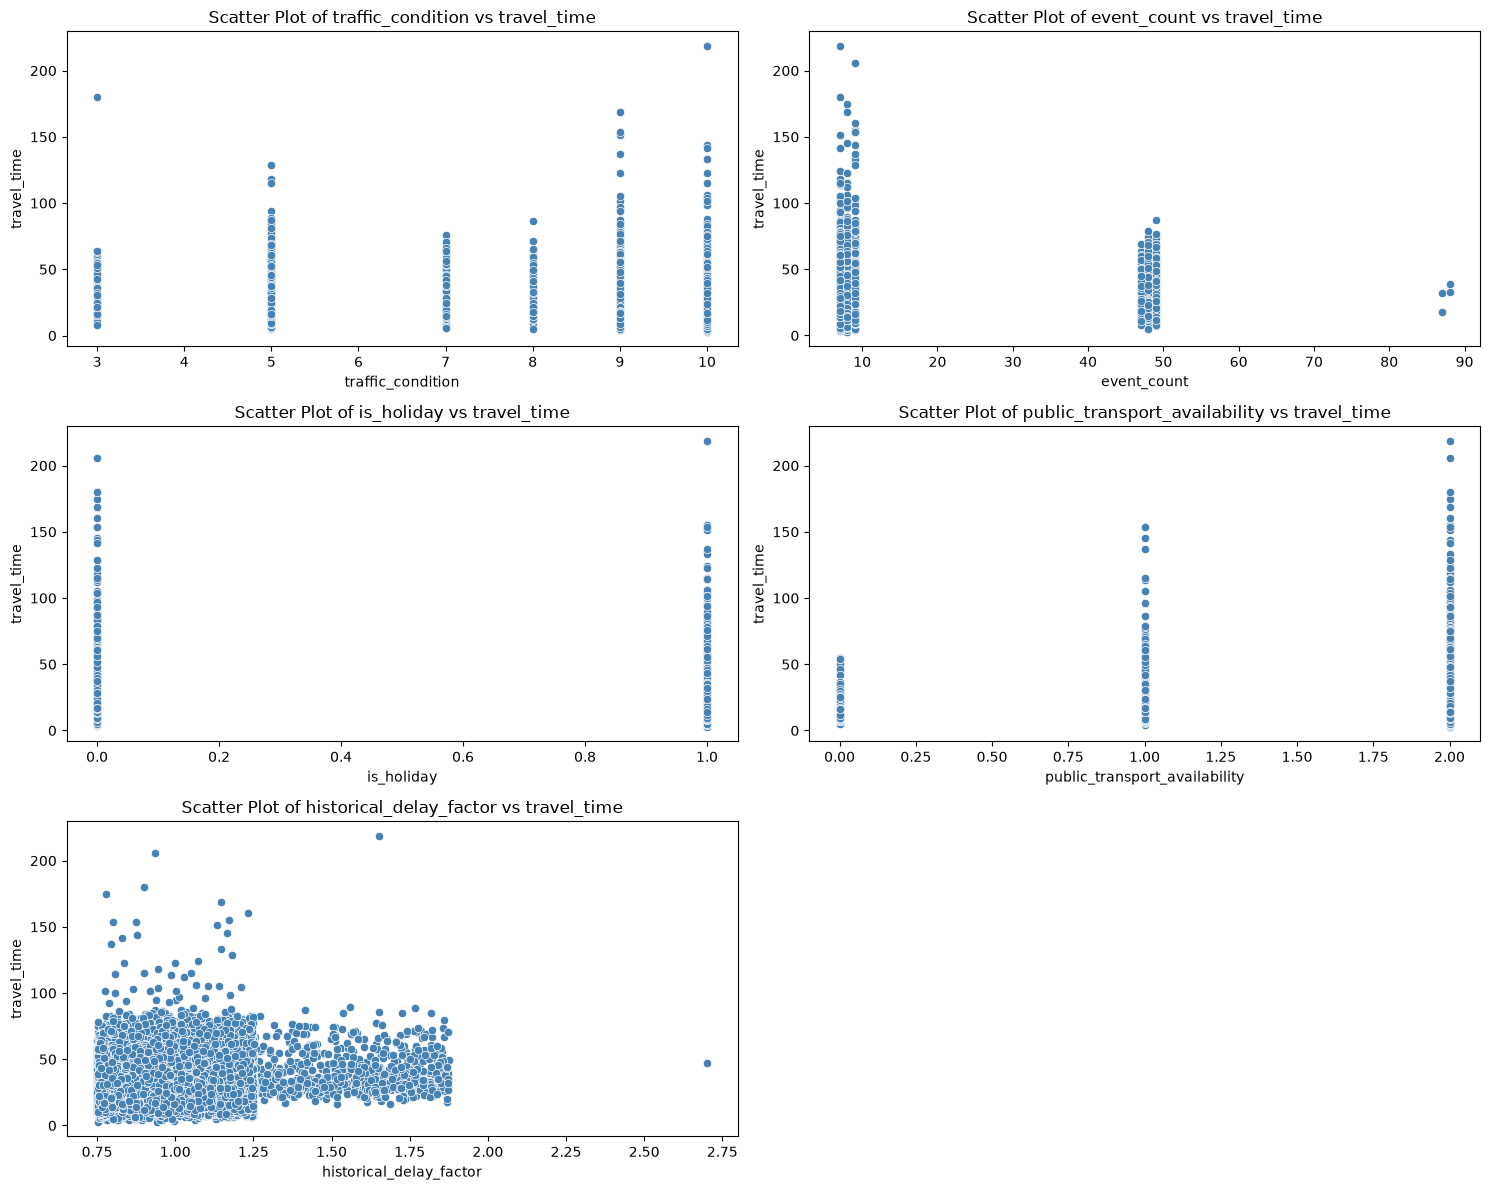

In [14]:
n_cols = 2
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=train_sample[col], y=train_sample['travel_time'], color='steelblue')
    plt.title(f"Scatter Plot of {col} vs travel_time")
    plt.xlabel(col)
    plt.ylabel("travel_time")

plt.tight_layout()

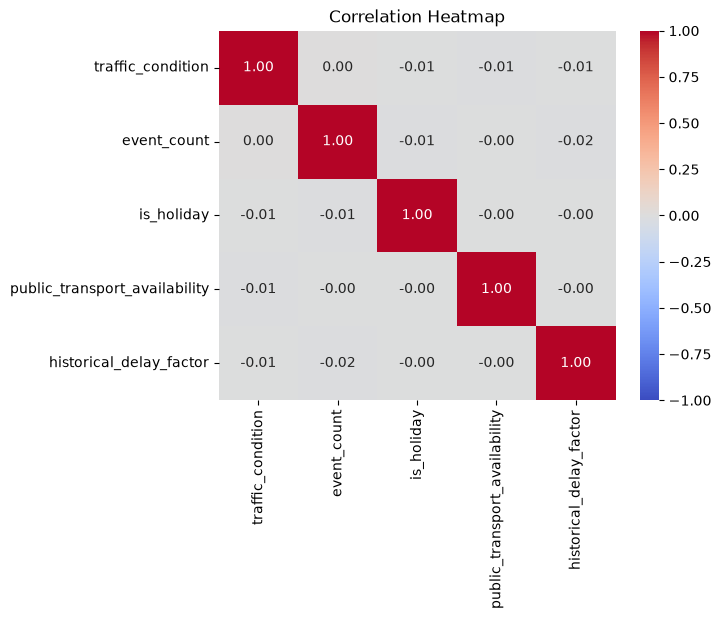

In [15]:
correlation = train_sample[numerical_columns].corr()
sns.heatmap(correlation,
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
           vmin=-1,
           vmax=1)
plt.title('Correlation Heatmap')
plt.show()